# Custom kernel: Rational Quadratic

> **Engine class: SSM-GP (AR(P) approximation)** - user-defined Rational Quadratic kernel has no closed-form SDE, so `KalmanEMEngine` lifts it through the same AR(P) bridge as MOSE. Tutorial: a new kernel needs only a `cov(τ)` method.


Tutorial: define a custom `BaseKernel` subclass and plug it into the SSM path via `kernel_factory_*`. The library doesn't need to be modified - any stationary scalar kernel with a `cov(Ï)` method works.

The kernel here is **Rational Quadratic (RQ)**:
$$k(\tau) = \left(1 + \frac{\tau^2}{2 \alpha \ell^2}\right)^{-\alpha}$$
With $\alpha \to \infty$ this recovers RBF; with $\alpha = 1$ it is the (heavy-tailed) Cauchy kernel. Leaving $\alpha$ free lets the optimizer interpolate.

Scenario: same as `demo_dlag_ssm.ipynb` so the figures compare like-for-like.

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch
from mbrila import DLAG, KalmanEMEngine, LatentSpec
from mbrila.kernels.base import BaseKernel
from mbrila.kernels.validate import check_kernel
from mbrila.synthetic.multiregion import MultiRegionScenario
from torch import Tensor, nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## The custom kernel

A `BaseKernel` subclass needs one method: `cov(tau: Tensor) -> Tensor`. Two learnable parameters (`log_lengthscale`, `log_alpha`) so they stay positive under unconstrained optimization.

In [2]:
class RationalQuadraticKernel(BaseKernel):
    """k(Ï) = (1 + ÏÂ² / (2 Î± ℓÂ²))^(-Î±).

    Î± -> ∞ recovers RBF; Î± = 1 is Cauchy. K(0) = 1 is fixed (only ℓ and
    Î± are learnable), matching MOSE - keeps the prior variance from
    competing with C during optimisation.
    """

    is_markovian = False  # no exact finite-state SDE -> uses AR(P) bridge
    is_complex = False

    def __init__(self, *, init_lengthscale: float = 2.0, init_alpha: float = 2.0) -> None:
        super().__init__()
        self.log_lengthscale = nn.Parameter(torch.log(torch.tensor(float(init_lengthscale))))
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(float(init_alpha))))

    def cov(self, tau: Tensor) -> Tensor:
        ell = torch.exp(self.log_lengthscale)
        alpha = torch.exp(self.log_alpha)
        return (1.0 + (tau / ell).square() / (2.0 * alpha)) ** (-alpha)


# Validate before plugging into the model - check_kernel raises if the
# kernel isn't even-symmetric, PSD, or boundary-consistent.
proto = RationalQuadraticKernel().to(dtype=torch.float64)
check_kernel(proto)
print(f"RQ kernel n_params = {proto.n_params}, capabilities = {sorted(proto.capabilities())}")

RQ kernel n_params = 2, capabilities = ['cov']


## Scenario

In [3]:
n_trials, T, n_regions = 50, 200, 5
y_dim_per_region, n_across, n_within = 100, 2, 1
sigma_across, sigma_within = 0.05, 0.05
delay_amplitude = 3.0
per_latent_sigma_ratio, per_latent_amp_ratio = 10.0, 3.0

scenario = MultiRegionScenario(  # noqa: F821
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=n_across,
    n_within=n_within,
    lag_across=2,
    lag_within=2,
    sigma_across=sigma_across,
    sigma_within=sigma_within,
    delay_shape="constant",
    delay_amplitude=delay_amplitude,
    per_latent_amplitudes=tuple(
        delay_amplitude * (1.0 / per_latent_amp_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    per_latent_shapes=tuple(["constant"] * n_across),
    region_heterogeneity=1.0,
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}"
)

data.y shape = (50, 200, 500)
truth['delay'] shape = (200, 4, 2)
truth['observable'] shape = (50, 200, 15)


## Build & fit model

In [4]:
spec = LatentSpec(
    n_across=n_across,
    n_within=(n_within,) * n_regions,
)
engine = KalmanEMEngine(
    lr=1e-2,
    lr_min=1e-3,
    weight_decay=1e-2,
    log_every=25,
)
init_ell, init_alpha = 2.0, 2.0


def kernel_factory() -> BaseKernel:
    return RationalQuadraticKernel(init_lengthscale=init_ell, init_alpha=init_alpha)


model = DLAG(
    latent_spec=spec,
    y_dims=scenario.y_dims,
    T=scenario.T,
    kernel_factory_across=kernel_factory,
    kernel_factory_within=kernel_factory,
    engine="kalman",
    engine_override=engine,
    device=device,
    dtype=torch.float64,
).to(device)

model.initialize_from_data(data, mode="pcca")

result = model.fit(data, max_iter=300, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[kalman_em] iter 25/300  E_q[log p(x,y)] = 1775829.299


[kalman_em] iter 50/300  E_q[log p(x,y)] = 1828068.861


[kalman_em] iter 75/300  E_q[log p(x,y)] = 1857881.760


[kalman_em] iter 100/300  E_q[log p(x,y)] = 1881912.039


[kalman_em] iter 125/300  E_q[log p(x,y)] = 1899568.087


...

[kalman_em] iter 225/300  E_q[log p(x,y)] = 1918074.898


[kalman_em] iter 250/300  E_q[log p(x,y)] = 1919309.563


[kalman_em] iter 275/300  E_q[log p(x,y)] = 1920143.804


[kalman_em] iter 300/300  E_q[log p(x,y)] = 1920776.015


fit done: 300 iters, wall = 330.7s


## Extract fitted quantities

In [5]:
fitted_delay = demo.extract_delay(model, scenario.T)
fitted_obs = demo.extract_observable(model, data)
fitted_y = demo.extract_y_recon(model, data)

fitted_obs_aligned, fitted_delay_aligned, perm = nb.align_and_repermute(
    truth["observable"],
    fitted_obs,
    fitted_delay,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
)
delay_rmse = demo.pair_rmse(fitted_delay_aligned, truth["delay"], n_regions)
print(f"across-latent permutation (truth -> fit slot) = {perm}")
print(f"delay_rmse after alignment = {delay_rmse:.4f} bins")

across-latent permutation (truth -> fit slot) = (0, 1)
delay_rmse after alignment = 0.0129 bins


## Figure 1 - Convergence

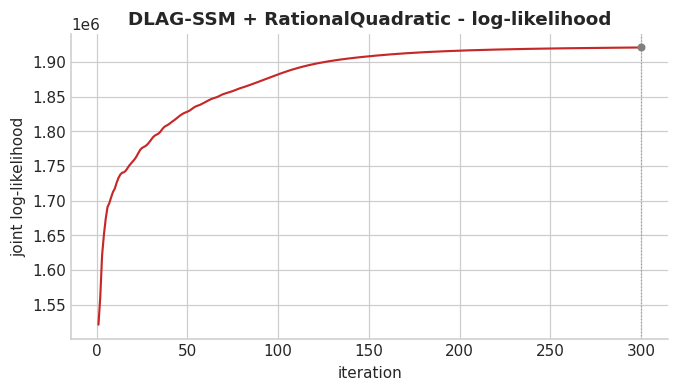

In [6]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="DLAG-SSM + RationalQuadratic - log-likelihood")

## Figure 2 - Delay comparison (truth vs fit, per pair)

One panel per `(latent, region pair)`. Truth dashed-purple, fit solid-darkred.

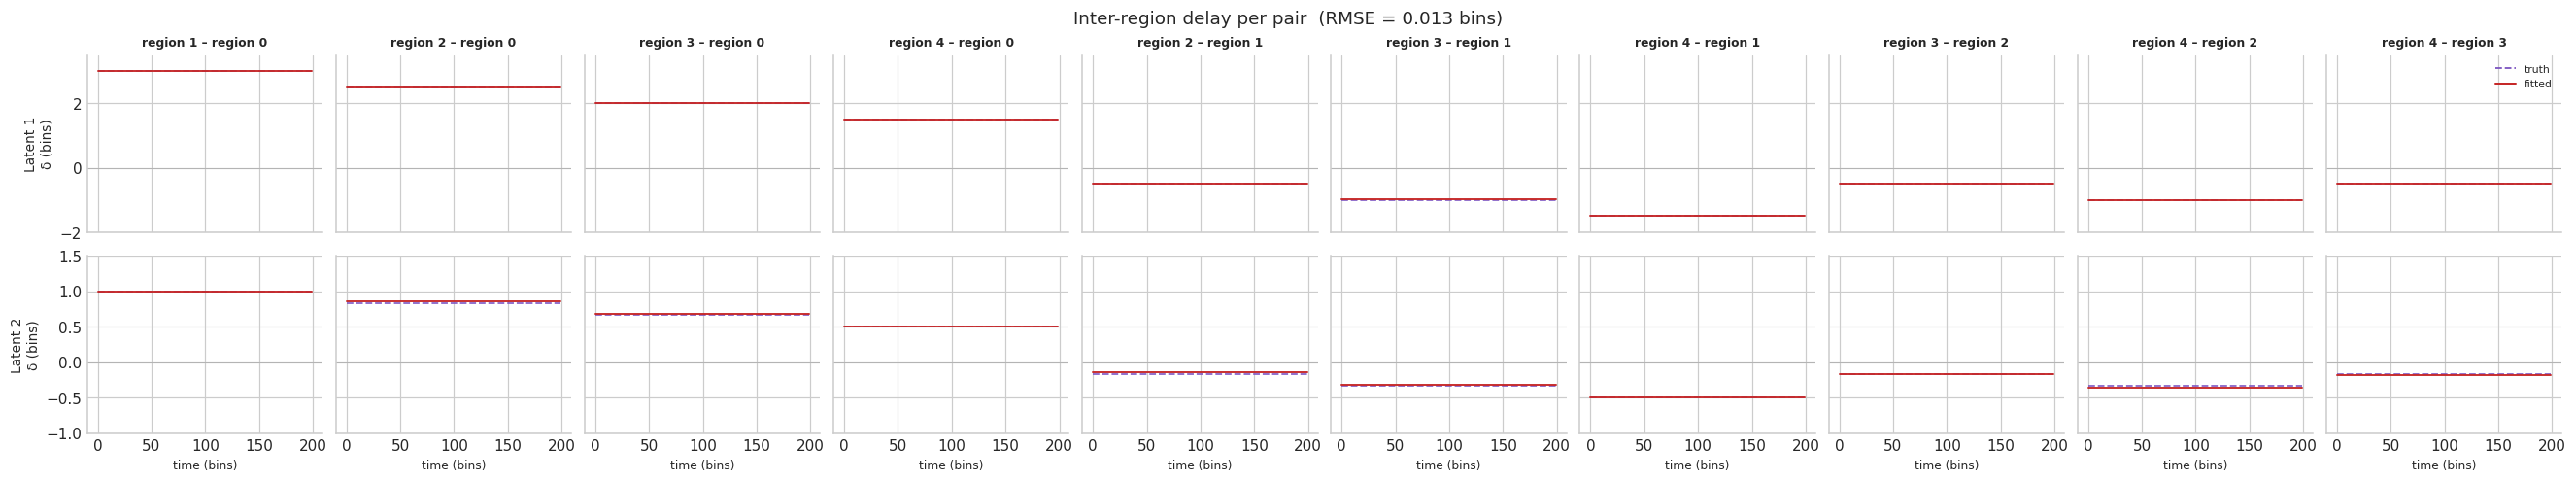

In [7]:
_ = nb.plot_delay_comparison(
    truth["delay"],
    fitted_delay_aligned,
    n_regions=n_regions,
    n_across=n_across,
    rmse=delay_rmse,
)

## Figure 3 - Per-latent traces (trial 0)

One panel per `(latent, region)`. Truth dashed, fit solid (sign-aligned per panel).

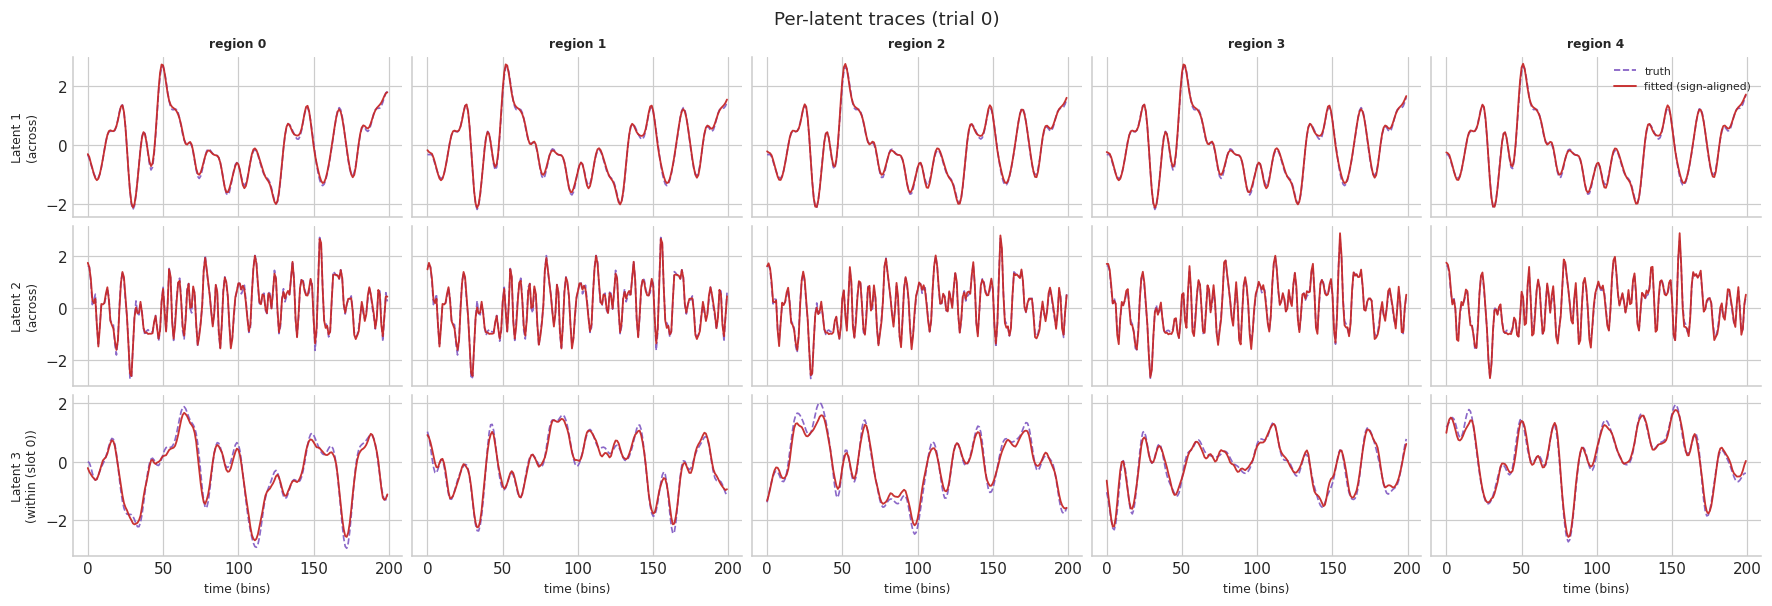

In [8]:
_ = nb.plot_latent_comparison(
    truth["observable"],
    fitted_obs_aligned,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
    trial=0,
)

## Figure 4 - PSTH matrix comparison

Trial-averaged $y$ -> neuron-by-time heatmap. Three panels: truth | fitted | $\text{fitted} - \text{truth}$. Neurons in natural region-grouped order; horizontal lines mark region boundaries; divergent `RdBu_r` colormap centred at 0.

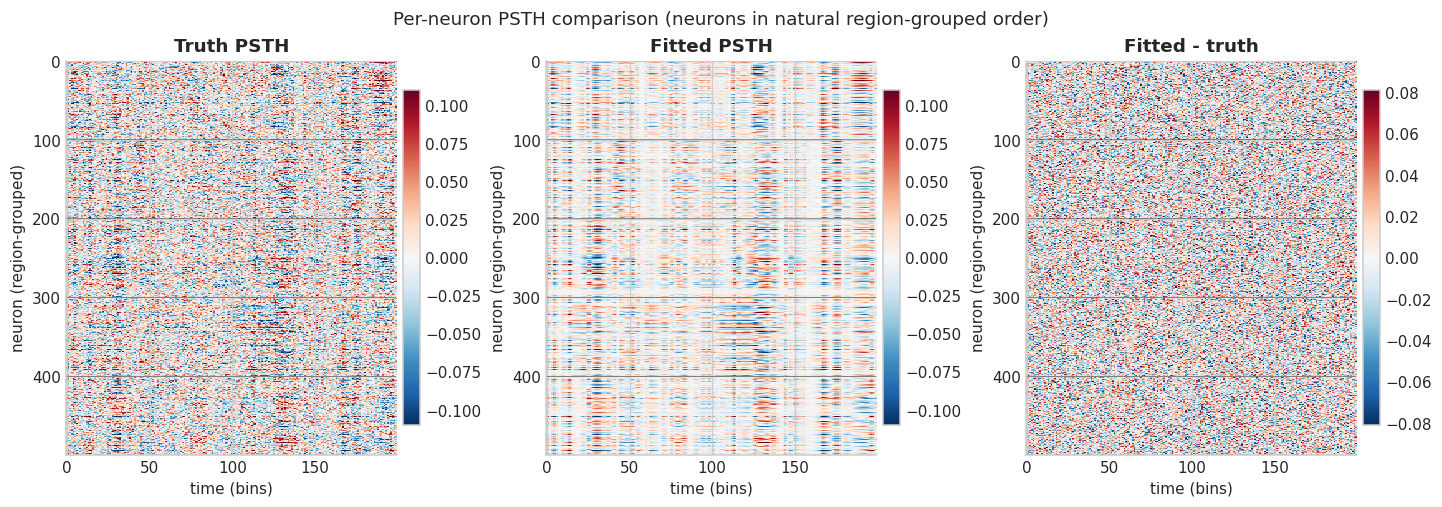

In [9]:
_ = nb.plot_psth_matrix(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
)

## Figure 5 - Trial-0 reconstruction (top-variance neurons per region)

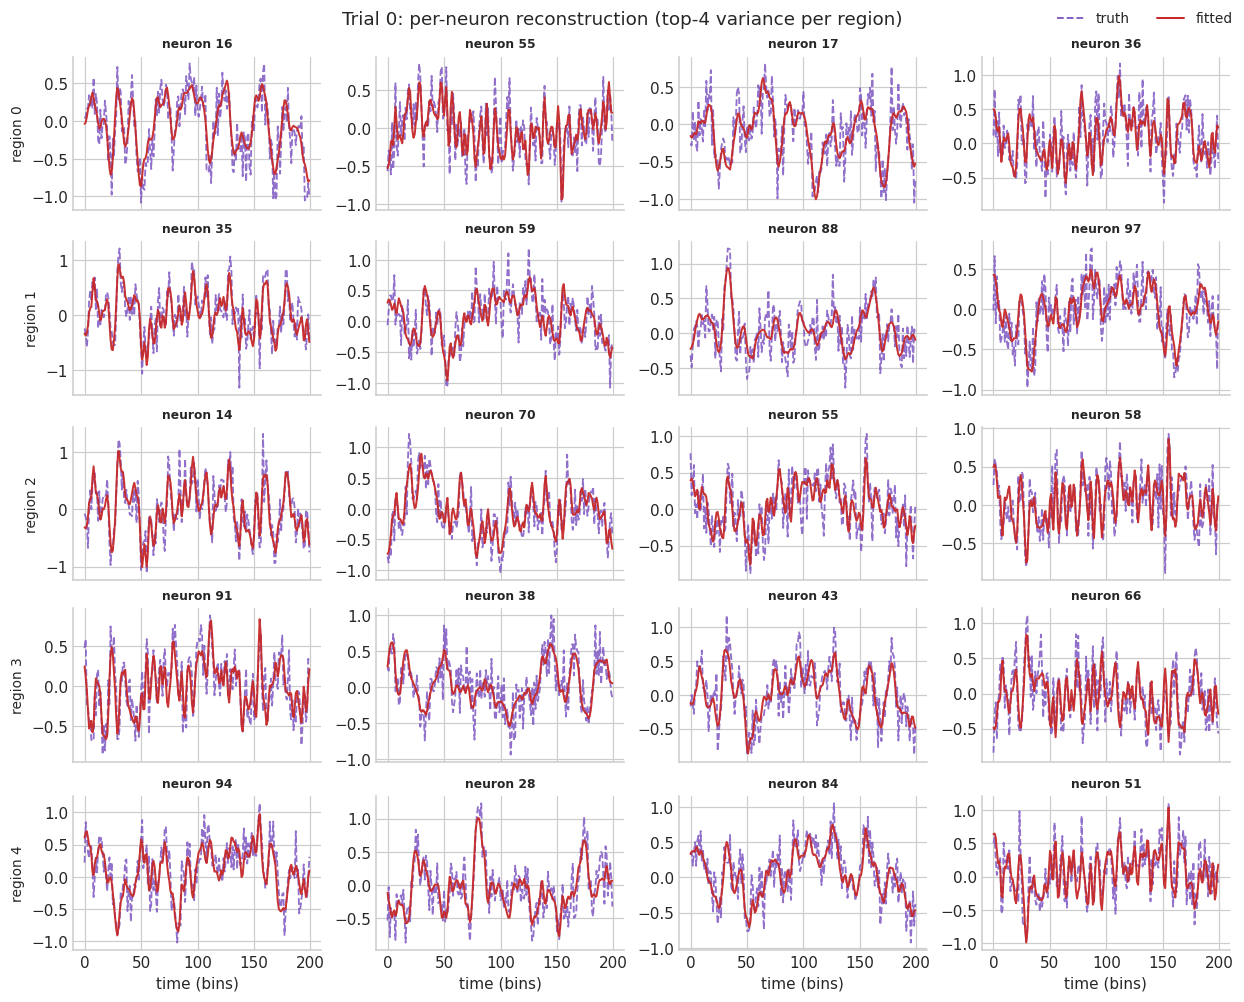

In [10]:
_ = nb.plot_trial0(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
    trial=0,
    n_per_region=4,
)

## Summary

In [11]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"delay_rmse        = {delay_rmse:.4f} bins")
print(f"y_rmse (overall)  = {y_info['overall']:.4f}")
print(f"y_rmse per region = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"across_perm       = {perm}")
print(f"wall time         = {result.wall_time_s:.1f}s")

delay_rmse        = 0.0129 bins
y_rmse (overall)  = 0.2229
y_rmse per region = ['0.2230', '0.2228', '0.2229', '0.2227', '0.2230']
across_perm       = (0, 1)
wall time         = 330.7s
